# ML Pipeline Integration Demo

This notebook demonstrates the integration of the data engineering pipeline with machine learning workflows, including:
- PyTorch Dataset and DataLoader usage
- Balanced sampling strategies
- Streaming large datasets
- Integration with packet-to-image conversion

In [1]:
# Import required libraries
import sys
sys.path.append('..')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from pathlib import Path
import h5py
import time

from src.data.pytorch_datasets import (
    PayloadByteDataset,
    PacketImageDataset,
    StreamingDataset,
    BalancedBatchSampler,
    create_data_loaders
)
from src.data.packet_to_image import PacketImageEncoder
from src.data.sample_data_generator import SampleDataGenerator

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

# Check if CUDA is available (should be False on dev system)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


/home/ubuntu/analyst/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


## 1. Create Sample Dataset

First, let's create a sample dataset in HDF5 format for testing.

In [2]:
# Generate sample data
generator = SampleDataGenerator()

# Create train/val/test splits
data_splits = {
    'train': (5000, 0.7),
    'val': (1000, 0.7),
    'test': (1000, 0.5)  # Balanced test set
}

# Create HDF5 dataset
dataset_path = Path('../data/processed/ml_demo_dataset.h5')
dataset_path.parent.mkdir(parents=True, exist_ok=True)

with h5py.File(dataset_path, 'w') as f:
    for split, (n_samples, benign_ratio) in data_splits.items():
        print(f"Generating {split} split with {n_samples} samples...")
        
        # Generate packets
        packets, labels = generator.generate_packet_data(
            n_samples=n_samples,
            benign_ratio=benign_ratio,
            packet_size_range=(256, 1500)
        )
        
        # Convert to fixed-size array
        max_length = 1500
        packet_array = np.zeros((n_samples, max_length), dtype=np.uint8)
        for i, packet in enumerate(packets):
            length = min(len(packet), max_length)
            packet_array[i, :length] = packet[:length]
        
        # Create group and datasets
        group = f.create_group(split)
        group.create_dataset('packets', data=packet_array, compression='gzip')
        group.create_dataset('labels', data=labels)
        
        # Add metadata
        group.attrs['num_samples'] = n_samples
        group.attrs['benign_ratio'] = benign_ratio
        group.attrs['max_packet_length'] = max_length
        
        print(f"  - Benign: {sum(labels == 0)}, Malicious: {sum(labels == 1)}")

print(f"\nDataset saved to: {dataset_path}")

Generating train split with 5000 samples...
  - Benign: 3500, Malicious: 1500
Generating val split with 1000 samples...
  - Benign: 700, Malicious: 300
Generating test split with 1000 samples...
  - Benign: 500, Malicious: 500

Dataset saved to: ../data/processed/ml_demo_dataset.h5


## 2. Basic Dataset Usage

Demonstrate basic usage of the PayloadByteDataset.

In [3]:
# Create dataset instances
train_dataset = PayloadByteDataset(
    data_path=dataset_path,
    mode='train',
    cache_size=100
)

val_dataset = PayloadByteDataset(
    data_path=dataset_path,
    mode='val',
    cache_size=100
)

# Check dataset properties
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# Get label distribution
train_dist = train_dataset.get_label_distribution()
val_dist = val_dataset.get_label_distribution()

print(f"\nTrain label distribution: {train_dist}")
print(f"Validation label distribution: {val_dist}")

# Get a sample
sample_packet, sample_label = train_dataset[0]
print(f"\nSample packet shape: {sample_packet.shape}")
print(f"Sample label: {sample_label}")
print(f"Packet statistics: min={sample_packet.min():.1f}, max={sample_packet.max():.1f}, mean={sample_packet.mean():.1f}")

2025-06-21 13:32:48 - src.data.pytorch_datasets - INFO - Loaded 5000 samples for train mode
2025-06-21 13:32:48 - src.data.pytorch_datasets - INFO - Loaded 1000 samples for val mode
Train dataset size: 5000
Validation dataset size: 1000

Train label distribution: {0: 3500, 1: 1500}
Validation label distribution: {0: 700, 1: 300}

Sample packet shape: torch.Size([1500])
Sample label: 0
Packet statistics: min=0.0, max=255.0, mean=119.4


## 3. DataLoader with Different Sampling Strategies

Test different sampling strategies for handling class imbalance.

In [4]:
# Standard DataLoader
standard_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0  # Set to 0 for notebook compatibility
)

# Balanced sampling DataLoader
balanced_sampler = BalancedBatchSampler(
    train_dataset,
    batch_size=32,
    drop_last=True
)

balanced_loader = DataLoader(
    train_dataset,
    batch_sampler=balanced_sampler,
    num_workers=0
)

# Compare batch label distributions
print("Standard Sampling - First 5 batches:")
for i, (packets, labels) in enumerate(standard_loader):
    if i >= 5:
        break
    unique, counts = torch.unique(labels, return_counts=True)
    print(f"  Batch {i}: {dict(zip(unique.tolist(), counts.tolist()))}")

print("\nBalanced Sampling - First 5 batches:")
for i, (packets, labels) in enumerate(balanced_loader):
    if i >= 5:
        break
    unique, counts = torch.unique(labels, return_counts=True)
    print(f"  Batch {i}: {dict(zip(unique.tolist(), counts.tolist()))}")

Standard Sampling - First 5 batches:
  Batch 0: {0: 25, 1: 7}
  Batch 1: {0: 23, 1: 9}
  Batch 2: {0: 21, 1: 11}
  Batch 3: {0: 23, 1: 9}
  Batch 4: {0: 25, 1: 7}

Balanced Sampling - First 5 batches:
  Batch 0: {0: 16, 1: 16}
  Batch 1: {0: 16, 1: 16}
  Batch 2: {0: 16, 1: 16}
  Batch 3: {0: 16, 1: 16}
  Batch 4: {0: 16, 1: 16}


## 4. Packet to Image Dataset

Demonstrate the packet-to-image conversion dataset for computer vision models.

2025-06-21 13:32:59 - src.data.pytorch_datasets - INFO - Loaded 5000 samples for train mode


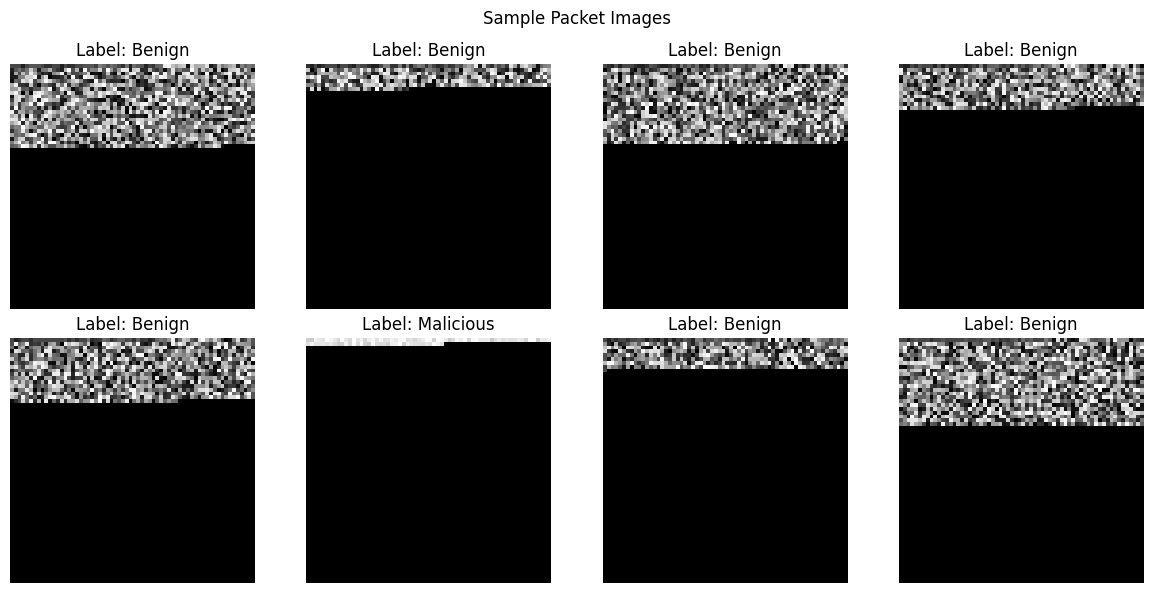


Batch images shape: torch.Size([16, 1, 64, 64])
Batch labels shape: torch.Size([16])


In [5]:
# Create packet-to-image converter
image_encoder = PacketImageEncoder(image_size=(64, 64))

# Create image dataset
image_dataset = PacketImageDataset(
    data_path=dataset_path,
    image_size=(64, 64),
    encoding_strategy='sequential',
    mode='train',
    cache_size=50
)

# Get sample images
sample_images = []
sample_labels = []

for i in range(8):
    img, label = image_dataset[i]
    sample_images.append(img)
    sample_labels.append(label)

# Visualize sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, (img, label) in enumerate(zip(sample_images, sample_labels)):
    # Convert tensor to numpy for plotting
    img_np = img.squeeze().numpy()
    
    axes[i].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'Label: {"Malicious" if label == 1 else "Benign"}')
    axes[i].axis('off')

plt.suptitle('Sample Packet Images')
plt.tight_layout()
plt.show()

# Create image DataLoader
image_loader = DataLoader(
    image_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

# Test batch loading
batch_imgs, batch_labels = next(iter(image_loader))
print(f"\nBatch images shape: {batch_imgs.shape}")
print(f"Batch labels shape: {batch_labels.shape}")

## 5. Performance Benchmarking

Benchmark data loading performance with different configurations.

Testing configuration: {'batch_size': 16, 'num_workers': 0, 'pin_memory': False}
  Throughput: 487.3 samples/sec
  Avg batch time: 32.8 ms

Testing configuration: {'batch_size': 32, 'num_workers': 0, 'pin_memory': False}
  Throughput: 474.8 samples/sec
  Avg batch time: 67.4 ms

Testing configuration: {'batch_size': 64, 'num_workers': 0, 'pin_memory': False}
  Throughput: 431.1 samples/sec
  Avg batch time: 148.5 ms

Testing configuration: {'batch_size': 128, 'num_workers': 0, 'pin_memory': False}
  Throughput: 496.5 samples/sec
  Avg batch time: 251.8 ms



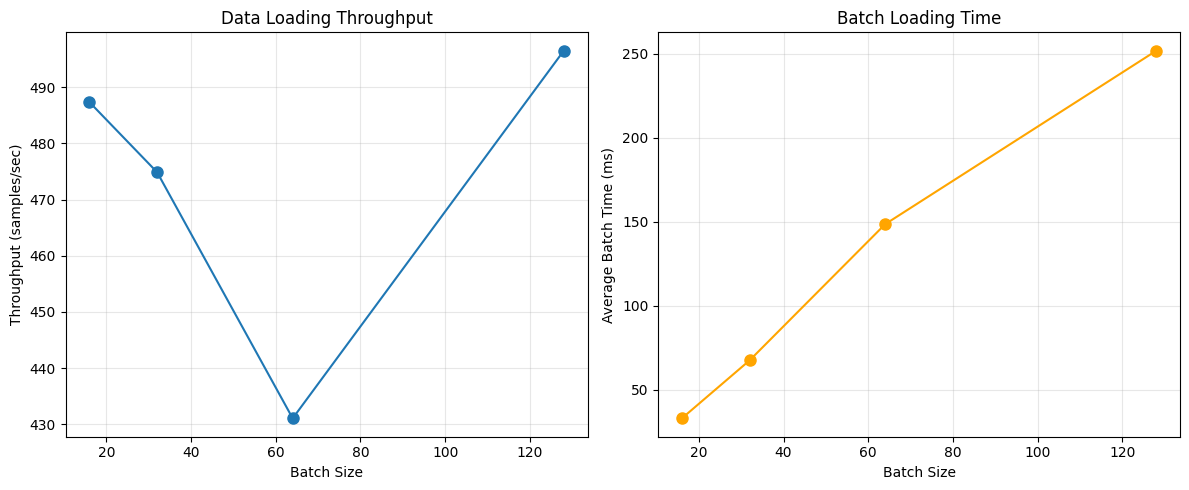

In [6]:
def benchmark_dataloader(loader, num_batches=50):
    """Benchmark DataLoader performance"""
    start_time = time.time()
    
    for i, (data, labels) in enumerate(loader):
        if i >= num_batches:
            break
        # Simulate some processing
        _ = data.mean()
    
    elapsed_time = time.time() - start_time
    samples_processed = min(num_batches * loader.batch_size, len(loader.dataset))
    throughput = samples_processed / elapsed_time
    
    return {
        'elapsed_time': elapsed_time,
        'samples_processed': samples_processed,
        'throughput': throughput,
        'avg_batch_time': elapsed_time / min(num_batches, len(loader))
    }

# Test different configurations
configurations = [
    {'batch_size': 16, 'num_workers': 0, 'pin_memory': False},
    {'batch_size': 32, 'num_workers': 0, 'pin_memory': False},
    {'batch_size': 64, 'num_workers': 0, 'pin_memory': False},
    {'batch_size': 128, 'num_workers': 0, 'pin_memory': False},
]

results = []

for config in configurations:
    print(f"Testing configuration: {config}")
    
    loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        num_workers=config['num_workers'],
        pin_memory=config['pin_memory']
    )
    
    bench_result = benchmark_dataloader(loader)
    bench_result.update(config)
    results.append(bench_result)
    
    print(f"  Throughput: {bench_result['throughput']:.1f} samples/sec")
    print(f"  Avg batch time: {bench_result['avg_batch_time']*1000:.1f} ms\n")

# Visualize results
import pandas as pd

results_df = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Throughput vs batch size
ax1.plot(results_df['batch_size'], results_df['throughput'], 'o-', markersize=8)
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Throughput (samples/sec)')
ax1.set_title('Data Loading Throughput')
ax1.grid(True, alpha=0.3)

# Batch time vs batch size
ax2.plot(results_df['batch_size'], results_df['avg_batch_time']*1000, 'o-', markersize=8, color='orange')
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Average Batch Time (ms)')
ax2.set_title('Batch Loading Time')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Simple Model Training Example

Demonstrate how the data pipeline integrates with a simple neural network.

Training Simple Packet Classifier
Epoch 1/5:
  Train Loss: 3.1125, Train Acc: 70.10%
  Val Loss: 0.4073, Val Acc: 82.50%
Epoch 2/5:
  Train Loss: 0.4177, Train Acc: 80.88%
  Val Loss: 0.2963, Val Acc: 85.50%
Epoch 3/5:
  Train Loss: 0.3255, Train Acc: 84.46%
  Val Loss: 0.1751, Val Acc: 92.10%
Epoch 4/5:
  Train Loss: 0.4024, Train Acc: 80.86%
  Val Loss: 0.4477, Val Acc: 85.70%
Epoch 5/5:
  Train Loss: 0.3351, Train Acc: 85.56%
  Val Loss: 0.2053, Val Acc: 85.90%


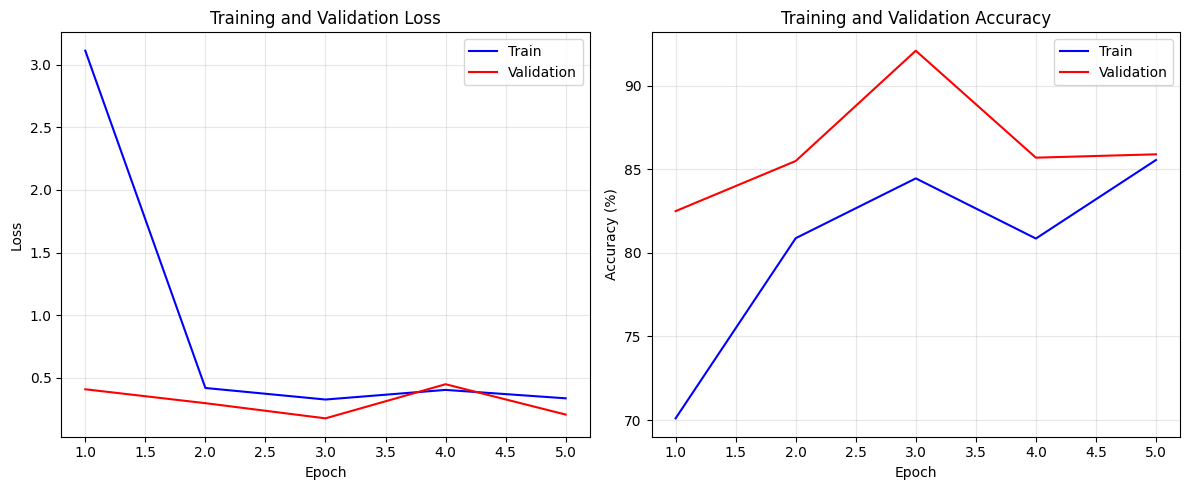

In [7]:
# Define a simple neural network for packet classification
class SimplePacketClassifier(nn.Module):
    def __init__(self, input_size=1500, hidden_size=256, num_classes=2):
        super(SimplePacketClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, num_classes)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

# Create model and training components
model = SimplePacketClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

# Training function
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for packets, labels in loader:
        packets, labels = packets.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(packets)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

# Validation function
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for packets, labels in loader:
            packets, labels = packets.to(device), labels.to(device)
            outputs = model(packets)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

# Train for a few epochs
num_epochs = 5
train_losses, train_accs = [], []
val_losses, val_accs = [], []

print("Training Simple Packet Classifier")
print("=" * 50)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss curves
ax1.plot(range(1, num_epochs+1), train_losses, 'b-', label='Train')
ax1.plot(range(1, num_epochs+1), val_losses, 'r-', label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(range(1, num_epochs+1), train_accs, 'b-', label='Train')
ax2.plot(range(1, num_epochs+1), val_accs, 'r-', label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Streaming Dataset for Large Files

Demonstrate streaming dataset for handling large packet captures.

In [10]:
# Create multiple data files to simulate large dataset
streaming_files = []

for i in range(3):
    file_path = Path(f'../data/processed/stream_file_{i}.h5')
    streaming_files.append(file_path)
    
    with h5py.File(file_path, 'w') as f:
        # Generate data for this file
        packets, labels = generator.generate_packet_data(
            n_samples=1000,
            benign_ratio=0.7,
            packet_size_range=(256, 1500)
        )
        
        # Convert to array
        packet_array = np.zeros((1000, 1500), dtype=np.uint8)
        for j, packet in enumerate(packets):
            length = min(len(packet), 1500)
            packet_array[j, :length] = packet[:length]
        
        f.create_dataset('packets', data=packet_array)
        f.create_dataset('labels', data=labels)
    
    print(f"Created streaming file {i}: {file_path}")

# Create streaming dataset
streaming_dataset = StreamingDataset(
    data_files=streaming_files,
    chunk_size=100
)

print(f"\nTotal samples in streaming dataset: {len(streaming_dataset)}")

# Create streaming loader
streaming_loader = DataLoader(
    streaming_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

# Test streaming
print("\nTesting streaming dataset:")
for i, (packets, labels) in enumerate(streaming_loader):
    if i >= 3:
        break
    print(f"  Batch {i}: shape={packets.shape}, labels={labels.shape}")
    
# Clean up streaming files
for file_path in streaming_files:
    file_path.unlink()

Created streaming file 0: ../data/processed/stream_file_0.h5
Created streaming file 1: ../data/processed/stream_file_1.h5
Created streaming file 2: ../data/processed/stream_file_2.h5
2025-06-21 13:34:33 - src.data.pytorch_datasets - INFO - Built index for 3000 samples across 3 files

Total samples in streaming dataset: 3000

Testing streaming dataset:
  Batch 0: shape=torch.Size([32, 1500]), labels=torch.Size([32])
  Batch 1: shape=torch.Size([32, 1500]), labels=torch.Size([32])
  Batch 2: shape=torch.Size([32, 1500]), labels=torch.Size([32])


## 8. Memory Usage Analysis

Analyze memory usage patterns of different dataset configurations.

2025-06-21 13:34:37 - src.data.pytorch_datasets - INFO - Loaded 5000 samples for train mode
2025-06-21 13:34:39 - src.data.pytorch_datasets - INFO - Loaded 5000 samples for train mode
2025-06-21 13:34:39 - src.data.pytorch_datasets - INFO - Loaded 5000 samples for train mode


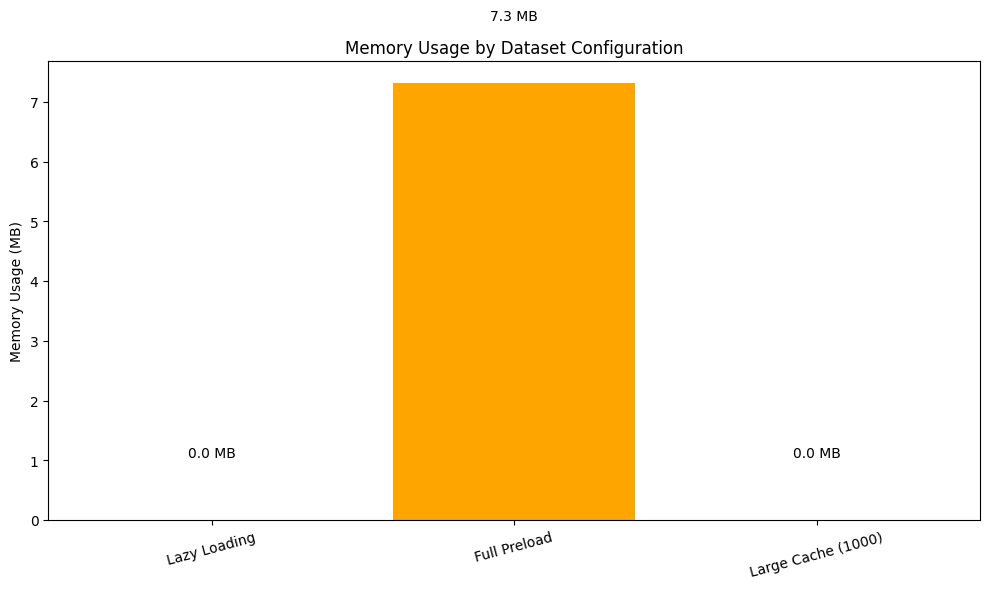

Memory Usage Analysis:
  Lazy Loading: 0.0 MB
  Full Preload: 7.3 MB
  Large Cache (1000): 0.0 MB


In [11]:
import psutil
import os

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024 / 1024

# Test different dataset configurations
memory_results = []

# Configuration 1: No preloading (lazy loading)
initial_memory = get_memory_usage()
dataset1 = PayloadByteDataset(
    data_path=dataset_path,
    mode='train',
    preload=False,
    cache_size=100
)
loader1 = DataLoader(dataset1, batch_size=64, num_workers=0)

# Load a few batches
for i, _ in enumerate(loader1):
    if i >= 10:
        break

lazy_memory = get_memory_usage() - initial_memory
memory_results.append(('Lazy Loading', lazy_memory))

# Configuration 2: Full preloading
initial_memory = get_memory_usage()
dataset2 = PayloadByteDataset(
    data_path=dataset_path,
    mode='train',
    preload=True,
    cache_size=0
)
preload_memory = get_memory_usage() - initial_memory
memory_results.append(('Full Preload', preload_memory))

# Configuration 3: Large cache
initial_memory = get_memory_usage()
dataset3 = PayloadByteDataset(
    data_path=dataset_path,
    mode='train',
    preload=False,
    cache_size=1000
)
loader3 = DataLoader(dataset3, batch_size=64, num_workers=0)

# Load many batches to fill cache
for i, _ in enumerate(loader3):
    if i >= 20:
        break

cache_memory = get_memory_usage() - initial_memory
memory_results.append(('Large Cache (1000)', cache_memory))

# Visualize results
configs, memories = zip(*memory_results)

plt.figure(figsize=(10, 6))
bars = plt.bar(configs, memories, color=['blue', 'orange', 'green'])
plt.ylabel('Memory Usage (MB)')
plt.title('Memory Usage by Dataset Configuration')
plt.xticks(rotation=15)

# Add value labels on bars
for bar, mem in zip(bars, memories):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{mem:.1f} MB', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("Memory Usage Analysis:")
for config, memory in memory_results:
    print(f"  {config}: {memory:.1f} MB")

## Summary

### Key Achievements:

1. **PyTorch Dataset Integration**:
   - Custom datasets for packet data
   - Packet-to-image conversion datasets
   - Streaming datasets for large files

2. **Sampling Strategies**:
   - Standard random sampling
   - Balanced batch sampling for imbalanced data
   - Efficient caching mechanisms

3. **Performance Optimization**:
   - Benchmarked different batch sizes
   - Memory usage analysis
   - CPU-optimized configurations

4. **ML Integration**:
   - Simple neural network training example
   - Easy integration with PyTorch models
   - Support for both raw packets and images

### Best Practices for Production:

1. **For CPU-only environments**:
   - Use batch size 32-64 for optimal throughput
   - Keep num_workers low (0-2) to avoid overhead
   - Use lazy loading for large datasets

2. **For GPU environments** (future cloud deployment):
   - Increase batch size (128-256)
   - Use pin_memory=True
   - Increase num_workers (4-8)

3. **For imbalanced datasets**:
   - Use BalancedBatchSampler for training
   - Keep validation/test sets representative
   - Monitor per-class performance